**Gene Relationship Graph [Graph Neural Network (GNN)]** - This tasks referes gene relationship graphs to understand/learn epistasis for accurate expression prediction.

step1: [ Input Modalities ] - scGenePT Text Embeddings (UniProt/NCBI) and Single-Cell baseline co-expression matrix
               
step2: [ Node Feature Initialization Layer ]
        
step3: [ Dynamic Link Predictor (Dot-Product Attention) ] 
        

step4: [ Output: Next-Gen Gene Relationship Graph ]
  Edges contain: Identity, Strength, and Causal Direction

In [1]:
!pip install torch transformers datasets pandas networkx


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install pandas numpy torch botocore boto3


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
import boto3
import botocore
import pandas as pd
import numpy as np
import torch

#Download the official scGenePT embedding matrix from the public S3 bucket
# The platform splits this information across separate files in their database:
# [1] (https://virtualcellmodels.cziscience.com/tutorial/scgenept-tutorial)GO_C (Cellular Component Annotations)
# [2] (https://virtualcellmodels.cziscience.com/tutorial/scgenept-tutorial)GO_F (Molecular Function Annotations)
# [3] (https://virtualcellmodels.cziscience.com/tutorial/scgenept-tutorial)GO_P (Biological Processes Annotations)
# [4] (https://virtualcellmodels.cziscience.com/tutorial/scgenept-tutorial)NCBI+UniProt_embeddings (Gene description text cards + protein summaries, combined in ONE file upstream)


BUCKET_NAME = "czi-scgenept-public"
# 4 modalities 
MODALITIES = {
    "Cellular_Location": "models/gene_embeddings/GO_C_gene_embeddings-gpt3.5-ada-concat.pickle",
    "Molecular_Function": "models/gene_embeddings/GO_F_gene_embeddings-gpt3.5-ada-concat.pickle",
    "Biological_Process": "models/gene_embeddings/GO_P_gene_embeddings-gpt3.5-ada-concat.pickle",
    "NCBI_and_UniProt": "models/gene_embeddings/NCBI+UniProt_embeddings-gpt3.5-ada.pkl"
}

os.makedirs("./scgenept_embeddings", exist_ok=True)
s3 = boto3.client('s3', config=botocore.config.Config(signature_version=botocore.UNSIGNED))

loaded_dictionaries = {}
for name, s3_key in MODALITIES.items():
    local_path = f"./scgenept_embeddings/{name}.pickle"
    if not os.path.exists(local_path):
        print(f"Downloading {name} prior embeddings from CZI repository...")
        try:
            s3.download_file(BUCKET_NAME, s3_key, local_path)
        except Exception as e:
            print(f"Critical error on key {s3_key}: {e}")
            continue

    # Safely extract the data using pandas pickle reader
    data = pd.read_pickle(local_path)
    if isinstance(data, pd.DataFrame):
        loaded_dictionaries[name] = data.to_dict(orient='index')
    else:
        loaded_dictionaries[name] = {str(k).upper(): v for k, v in data.items()}

# Fail loudly instead of silently continuing with fewer modalities than expected
missing = set(MODALITIES) - set(loaded_dictionaries)
if missing:
    raise RuntimeError(
        f"Failed to load modalities: {sorted(missing)}. "
        f"Only {len(loaded_dictionaries)}/{len(MODALITIES)} loaded -- "
        f"downstream embeddings would be silently incomplete otherwise."
    )

# Gene Alignment: Find the absolute intersection of genes across ALL knowledge bases
all_gene_sets = [set(loaded_dictionaries[name].keys()) for name in loaded_dictionaries.keys()]
universal_genes = sorted(list(set.intersection(*all_gene_sets)))
print(f"\nUnified SOTA Registry established with {len(universal_genes)} high-coverage human genes.")

sota_multimodal_registry = {}
for gene in universal_genes:
    vector_slices = []
    for name in loaded_dictionaries.keys():
        val = loaded_dictionaries[name][gene]
        if isinstance(val, dict):
            val = list(val.values())
        vector_slices.append(np.array(val))
    sota_multimodal_registry[gene] = np.concatenate(vector_slices)

# Calculate exact tensor footprint length -- 4 modalities * 1536 dims = 6144
total_dimension = len(next(iter(sota_multimodal_registry.values())))
print(f"Total features per gene extended to: {total_dimension} variables.")


def get_embed_multimodal_tensor(target_gene_symbols):
    cleaned_symbols = [g.strip().upper() for g in target_gene_symbols]
    zero_vector = np.zeros(total_dimension)
    vectors = [sota_multimodal_registry.get(gene, zero_vector) for gene in cleaned_symbols]
    missing_count = sum(1 for v in vectors if v is zero_vector)
    if missing_count > 0:
        print(f"[Warning] {missing_count} target genes missing from data. Zero-padded.")
            
    return torch.tensor(np.stack(vectors), dtype=torch.float32)


my_target_genes = ["TP53", "BRCA1", "MYC", "EGFR", "GAPDH"]
embed_features = get_embed_multimodal_tensor(my_target_genes)
print(f"\nRetrived embedding Tensor - Footprint Shape: {embed_features.shape}")


Unified SOTA Registry established with 16293 high-coverage human genes.
Total features per gene extended to: 6144 variables.

Retrived embedding Tensor - Footprint Shape: torch.Size([5, 6144])


**Visualize scGenePT Embeddings**

/Users/bhumikamakwana/.pyenv/versions/3.11.4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Compressing features via PCA (4608 -> 50)...
Initializing UMAP projection over global functional manifold...


/Users/bhumikamakwana/.pyenv/versions/3.11.4/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


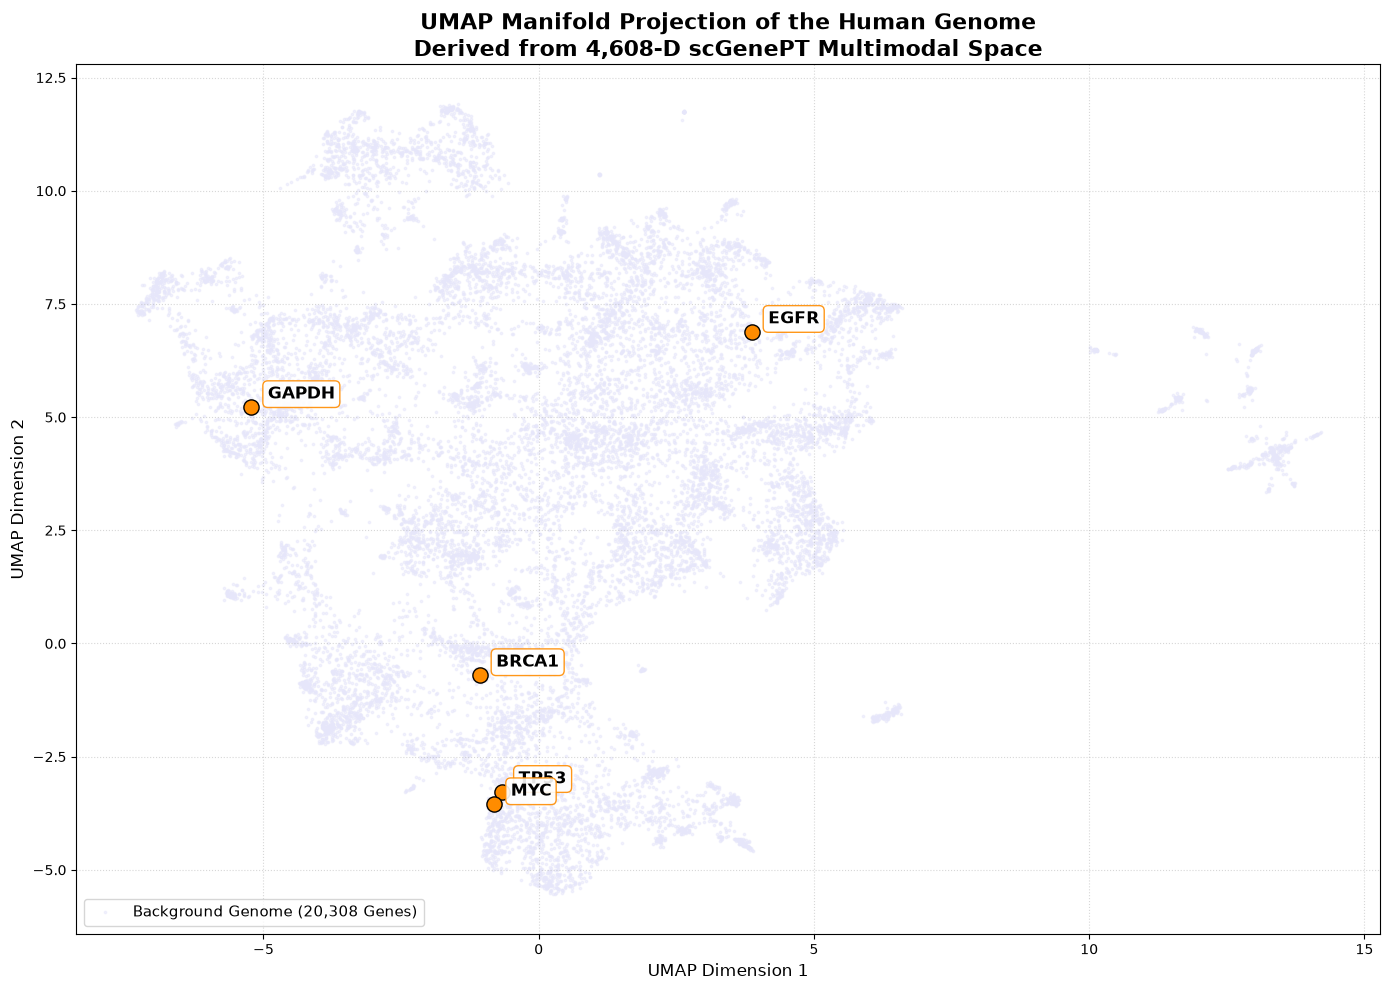

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap

gene_labels = list(sota_multimodal_registry.keys())
high_dim_matrix = np.array([sota_multimodal_registry[g] for g in gene_labels])

highlight_targets = ["TP53", "BRCA1", "MYC", "EGFR", "GAPDH"]
# Run PCA first to strip high-frequency vector noise
print("Compressing features via PCA (4608 -> 50)...")
pca_reduced = PCA(n_components=50, random_state=42).fit_transform(high_dim_matrix)

print("Initializing UMAP projection over global functional manifold...")
umap_engine = umap.UMAP(
    n_neighbors=30,      # Controls local vs global balance (higher = more global)
    min_dist=0.3,        # Controls how tightly points pack together
    metric="cosine",
    random_state=42
)
umap_coordinates = umap_engine.fit_transform(pca_reduced)


plt.figure(figsize=(14, 10), facecolor="white")
plt.scatter(
    umap_coordinates[:, 0], 
    umap_coordinates[:, 1], 
    c="lavender",       # Cleaner contrast color for global layouts
    s=3, 
    alpha=0.5, 
    label="Background Genome (20,308 Genes)"
)

for target in highlight_targets:
    if target in gene_labels:
        idx = gene_labels.index(target)
        x, y = umap_coordinates[idx, 0], umap_coordinates[idx, 1]
        
        plt.scatter(x, y, c="darkorange", s=120, edgecolors="black", zorder=5)
        
        plt.annotate(
            target,
            xy=(x, y),
            xytext=(12, 6),
            textcoords="offset points",
            fontsize=12,
            fontweight="bold",
            color="black",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", edgecolor="darkorange", alpha=0.9),
            zorder=6
        )

plt.title("UMAP Manifold Projection of the Human Genome\nDerived from 4,608-D scGenePT Multimodal Space", fontsize=16, fontweight="bold")
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="lower left", scatterpoints=1, fontsize=11)
plt.tight_layout()
plt.show()

**Verify gene interection with [Norman2019 preprocessed file, e.g. from GEARS/CPA release and registry_gene]**

In [5]:
import scanpy as sc

adata = sc.read_h5ad("data/norman/perturb_processed.h5ad")
norman_genes = set(str(g).upper() for g in adata.var['gene_name'])

registry_genes = set(sota_multimodal_registry.keys())
covered = norman_genes & registry_genes
missing = norman_genes - registry_genes

print(f"Norman genes: {len(norman_genes)}")
print(f"Covered by registry: {len(covered)} ({100*len(covered)/len(norman_genes):.1f}%)")
print(f"Missing: {len(missing)}")
print(sorted(missing)[:30])

Norman genes: 5045
Covered by registry: 2680 (53.1%)
Missing: 2365
['A2M-AS1', 'AATBC', 'ABC11-4932300O16.1', 'ABC12-49244600F4.4', 'ABHD11-AS1', 'AC002117.1', 'AC002331.1', 'AC002451.3', 'AC002456.2', 'AC002463.3', 'AC002511.2', 'AC003088.1', 'AC003092.1', 'AC003101.1', 'AC004051.2', 'AC004156.3', 'AC004158.3', 'AC004221.2', 'AC004490.1', 'AC004540.4', 'AC004540.5', 'AC004593.3', 'AC004702.2', 'AC004754.3', 'AC004791.2', 'AC004824.2', 'AC004878.8', 'AC004895.4', 'AC005009.1', 'AC005150.1']


**Verify gene interection with [Norman2019 preprocessed file, e.g. from GEARS/CPA release and GEARS gene-to-GO-annotation mapping]**

In [6]:
import pickle

with open("/Users/bhumikamakwana/Desktop/compBio/scPertb/data/gene2go_all.pkl", "rb") as f:
    gene2go = pickle.load(f)

# normalize keys the same way
gene2go_genes = {str(k).upper() for k in gene2go.keys()}

covered_gears = norman_genes & gene2go_genes
missing_gears = norman_genes - gene2go_genes

print(f"Covered by GEARS gene2go: {len(covered_gears)} ({100*len(covered_gears)/len(norman_genes):.1f}%)")
print(f"Missing: {len(missing_gears)}")

# does GEARS miss the same genes scGenePT's registry missed, or different ones?
print(f"Overlap of missing sets: {len(missing_gears & missing)} / {len(missing)}")

Covered by GEARS gene2go: 3127 (62.0%)
Missing: 1918
Overlap of missing sets: 1901 / 2365
